# Text Mining aplicado a la Tesorería de Tucuman

## Problema

Se desarrolló un documento disponible en https://docs.google.com/document/d/1QpHmWQ-QzxrsqB8v-XjnfeSde37s38dsABlI-wB2-g4/edit

Repositorio: https://github.com/ivanjavierparra/Text-Mining-Austral

Diccionario de datos

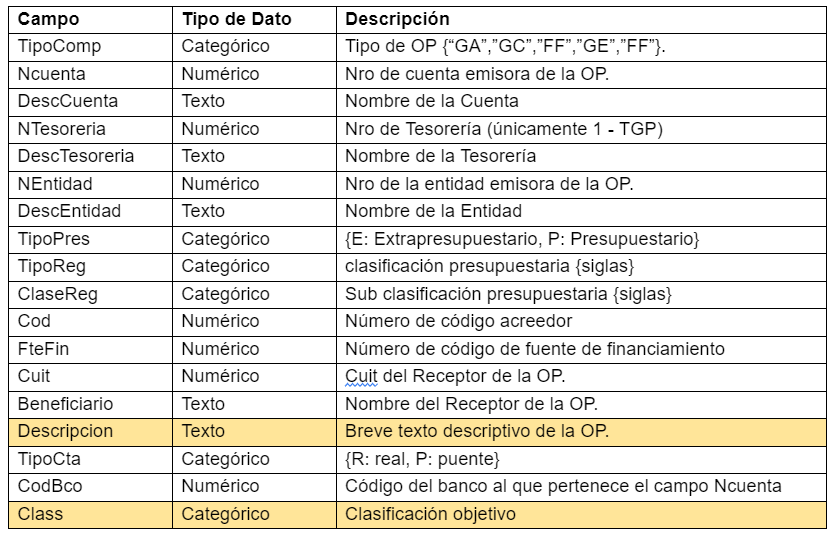

Bibliotecas

In [1]:
import nltk
nltk.download()

showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml


True

In [3]:
import pandas as pd
import preprocessing
import train_lightgbm
import train_onevsrest
import train_rn
import warnings
import os
warnings.filterwarnings("ignore")

In [ ]:
# df = pd.read_excel("./datasets/df.xlsx")
# largo = len(df)
# # train: 40%, val: 30%, test: 30%
# df_train = df.iloc[:int(0.4*largo), :]
# df_val = df.iloc[int(0.4*largo):int(0.7*largo), :]
# df_test = df.iloc[int(0.7*largo):, :]

# df_train.to_csv("./datasets/df_train.csv", index=False)
# df_val.to_csv("./datasets/df_val.csv", index=False)
# df_test.to_csv("./datasets/df_test.csv", index=False)

Creacion de carpetas para los modelos

In [4]:
os.makedirs("models",exist_ok=True)
os.makedirs("models/lgbm", exist_ok=True)
os.makedirs(f"models/lgbm/modelo_base", exist_ok=True)   
os.makedirs(f"models/lgbm/modelo_text_mining", exist_ok=True)   
os.makedirs(f"models/lgbm/modelo_completo", exist_ok=True)   
os.makedirs(f"models/lgbm/modelo_tfidf", exist_ok=True)   


os.makedirs("models",exist_ok=True)
os.makedirs("models/onevsrest", exist_ok=True)
os.makedirs(f"models/onevsrest/modelo_base", exist_ok=True)   
os.makedirs(f"models/onevsrest/modelo_text_mining", exist_ok=True)   
os.makedirs(f"models/onevsrest/modelo_completo", exist_ok=True)   
os.makedirs(f"models/onevsrest/modelo_tfidf", exist_ok=True)   


os.makedirs("models",exist_ok=True)
os.makedirs("models/randomforest", exist_ok=True)
os.makedirs(f"models/randomforest/modelo_base", exist_ok=True)   
os.makedirs(f"models/randomforest/modelo_text_mining", exist_ok=True)   
os.makedirs(f"models/randomforest/modelo_completo", exist_ok=True)   
os.makedirs(f"models/randomforest/modelo_tfidf", exist_ok=True)   

## EDA

Hicimos un Notebook a parte llamdo __EDA.ipynb__

## Preprocessing

In [9]:
import importlib
import preprocessing
importlib.reload(preprocessing)
preprocessing.preprocess("./datasets")

Iniciando preprocesamiento de train/val/test...

[1/6] Leyendo train desde: /home/francisco/maestrìa/trabajo final/tf-austral/datasets/2022-2023.csv
   ✓ train: 46366 registros, 18 columnas

[1/6] Leyendo val desde: /home/francisco/maestrìa/trabajo final/tf-austral/datasets/2024.csv
   ✓ val: 55919 registros, 42 columnas

[1/6] Leyendo test desde: /home/francisco/maestrìa/trabajo final/tf-austral/datasets/2025.csv
   ✓ test: 50352 registros, 53 columnas

[2/6] Seleccionando columnas necesarias...
   ✓ train: 12 columnas
   ✓ val: 12 columnas
   ✓ test: 12 columnas

[3/6] Imputando valores NA...
   - NAs en 'descripcion': 0
   - NAs en 'clase_reg': 0
   - NAs en 'descripcion': 0
   - NAs en 'clase_reg': 0
   - NAs en 'descripcion': 0
   - NAs en 'clase_reg': 1455
   ✓ Valores NA imputados en todos los splits

[4/6] Convirtiendo 'Class' a valores numéricos con el mapeo del train...
   - Clases encontradas (train): ['GF', 'PTE', 'Sueldos', 'Viaticos', 'Proveedores', 'FF', 'Servicios', 'Re

Aquí lo que hicimos fue:
- eliminamos columnas que no servían, 
- imputamos NA's
- Covertimos el campo Class de categórico a numérico (es nuestra variable target)
- hicimos un preprocesamiento de texto

Procesamiento de texto:
- Quedarnos solo con los números y letras: expresiones regulares
- Separar el texto de los números
- Eliminar espacios adicionales
- Eliminar las stopwords
- Aplicar tokenización y lematización
- Filtrar aquellas palabras cuya longitud es mínimo 3 caracteres. 

## Feature Engineering

In [5]:
import importlib 
import feature_engineering
importlib.reload(feature_engineering)
feature_engineering.fe("./datasets")

Iniciando Feature Engineering sobre train/val/test...

[1/7] Leyendo datos preprocesados...
   ✓ train: 18546 registros, 25 columnas
   ✓ val: 13910 registros, 25 columnas
   ✓ test: 13911 registros, 25 columnas

[2/7] Creando variables de texto...
   - Variables creadas: descripcion_size, descripcion_words_count, text_size, text_words_count
   - Variables creadas: descripcion_size, descripcion_words_count, text_size, text_words_count
   - Variables creadas: descripcion_size, descripcion_words_count, text_size, text_words_count
   ✓ Variables creadas para train/val/test

[3/7] Eliminando variables innecesarias...
   ✓ train: columna 'Descripcion' eliminada. Columnas restantes: 28
   ✓ val: columna 'Descripcion' eliminada. Columnas restantes: 28
   ✓ test: columna 'Descripcion' eliminada. Columnas restantes: 28

[4/7] OneHotEncoding ya fue aplicado en el preprocesamiento

[5/7] Calculando diccionario de palabras (solo train)...
   - Procesando clase 0 (1/25)...
   - Procesando clase 1 (

{'train':                Ncuenta  NEntidad TipoPres  Cod  FteFin  CodBco  target  \
 0      360000003873122        50        E  229      10       7       0   
 1             71111333        50        E  229      10       7       1   
 2             71111333        50        E  229      10       7       1   
 3      360000003873122        50        E  225      10       7       2   
 4      360000003873122        50        E  225      10       7       2   
 ...                ...       ...      ...  ...     ...     ...     ...   
 18541  360000003873122        33        P    0      10       7       9   
 18542  360000003873122        33        P    0      10       7       9   
 18543  360000003873122        33        P    0      10       7       9   
 18544  360000003873122        33        P    0      10       7       9   
 18545  360000003873122        33        P    0      10       7       9   
 
                                             texto_limpio  TipoComp_AF  \
 0            A

Lo que hicimos fue:
- Crear variables de texto tanto para la Descripción sin procesar como procesada: longitud, cantidad de palabras.
- Aplicar OneHotEncoding a las variables categóricas
- Asignamos pesos a las palabras del campo texto_limpio
- Estandarizamos los pesos anteriores

## Modelos

Para el presente trabajo, decidimos utilizar tres algoritmos y evaluar su performance:
- LightGBM
- Gradient Boosting
- Random Forest

Decidimos crear 4 escenarios para cada uno de los modelos:
- Escenario 1: lo llamamos modelo_base, y consiste en usar los datos crudos, sin aplicar el preprocesamiento de texto.
- Escenario 2: lo llamamos modelo_text_mining: aplicamos preprocesamiento y feature engineering completo, acá ya tenemos los pesos calculados.
- Escenario 3: lo llamamos modelo_completo. Al el Escenario 2 le agregamos TF-IDF
- Escenario 4: lo llamamos modelo_tf_idf porque solo usamos como input la salida de este modelo.

In [6]:
study_name = "prueba lgbm"

In [7]:
import importlib 
importlib.reload(train_lightgbm)
train_lightgbm.modelo_completo(100,"sincuit")

[2025-12-20 11:56:43.764202] - Leyendo train desde /home/francisco/projects/Text-Mining-Austral/trabajo_final/datasets/df_final_train.csv


[2025-12-20 11:56:44.024800] - Leyendo val desde /home/francisco/projects/Text-Mining-Austral/trabajo_final/datasets/df_final_val.csv


[I 2025-12-20 11:56:45,179] Using an existing study with name 'lightgbm_sincuit' instead of creating a new one.
[I 2025-12-20 11:57:04,113] Trial 21 finished with value: 0.15088882833329564 and parameters: {'learning_rate': 0.09211088052638018, 'num_leaves': 112, 'max_depth': 11, 'min_child_samples': 77, 'subsample': 0.8896299489246043, 'colsample_bytree': 0.8789498267565891, 'reg_alpha': 8.729776486963512e-06, 'reg_lambda': 1.214616235062987e-06}. Best is trial 19 with value: 0.9837856593212243.
[I 2025-12-20 11:57:22,260] Trial 22 finished with value: 0.9591499906330332 and parameters: {'learning_rate': 0.03987615686421985, 'num_leaves': 128, 'max_depth': 8, 'min_child_samples': 92, 'subsample': 0.8075902977055496, 'colsample_bytree': 0.9407282030185755, 'reg_alpha': 0.0005738349596969346, 'reg_lambda': 1.1180428613711866e-08}. Best is trial 19 with value: 0.9837856593212243.
[I 2025-12-20 11:57:32,918] Trial 23 finished with value: 0.949917808548693 and parameters: {'learning_rate':

[2025-12-20 12:26:54.152702] - Mejores hiperparámetros: {'learning_rate': 0.03687124714559216, 'num_leaves': 126, 'max_depth': 9, 'min_child_samples': 94, 'subsample': 0.8798655525274242, 'colsample_bytree': 0.8873483129038707, 'reg_alpha': 0.0007270289426969635, 'reg_lambda': 1.3424629832955331e-06}

[2025-12-20 12:26:54.166847] - Entrenando modelo con los mejores hiperparametros.. 

[2025-12-20 12:27:27.162936] - Se ha guardado el modelo en models/lgbm/sincuit/model_sincuit.pkl 

